In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
import random
import math

In [2]:
newdf = pd.read_csv('batdongsan.com.vn.csv', dtype = {"month": str, "id": str})
newdf.head()

,id,month,project,investor,square,bedrooms,bathrooms,direction,balcony,district,ward,price
0,28086120,12,Vinhomes Smart City Đại Mỗ,Tập đoàn Vingroup,60.0,3.0,1.0,Đông-Nam,Tây-Bắc,nam tu liem,dai mo,1560.0
1,28088954,12,Goldmark City,Công ty TNHH Thương mại - Quảng cáo - Xây dựng...,121.0,3.0,2.0,NaN,NaN,bac tu liem,phu dien,3300.0
2,28097966,12,Chung cư IEC Tứ Hiệp,NaN,70.0,2.0,2.0,Tây-Bắc,Đông-Nam,thanh tri,tu hiep,1106.0
3,27895887,12,Vinhomes D'Capitale,Tân Hoàng Minh Group,39.0,1.0,1.0,Đông-Nam,Đông-Nam,cau giay,trung hoa,1500.0
4,28056031,12,The Zen Residence,Công ty TNHH Gamuda Land Việt Nam,97.0,3.0,2.0,NaN,NaN,hoang mai,hoang liet,2900.0


In [3]:
newdf.columns

Index(['id', 'month', 'project', 'investor', 'square', 'bedrooms', 'bathrooms',
       'direction', 'balcony', 'district', 'ward', 'price'],
      dtype='str')

In [4]:
newdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 81163 entries, 0 to 81162
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         81163 non-null  str    
 1   month      81162 non-null  str    
 2   project    78097 non-null  str    
 3   investor   65453 non-null  str    
 4   square     81162 non-null  float64
 5   bedrooms   81162 non-null  float64
 6   bathrooms  81162 non-null  float64
 7   direction  51086 non-null  str    
 8   balcony    54426 non-null  str    
 9   district   81162 non-null  str    
 10  ward       79506 non-null  str    
 11  price      81162 non-null  float64
dtypes: float64(4), str(8)
memory usage: 7.4 MB


In [5]:
newdf.describe()

,square,bedrooms,bathrooms,price
count,81162.000000,81162.000000,81162.000000,81162.000000
mean,83.481974,2.365602,1.897785,2404.748090
std,25.662160,0.622283,0.404293,1038.825418
min,7.000000,1.000000,1.000000,350.000000
25%,66.000000,2.000000,2.000000,1520.000000
50%,79.000000,2.000000,2.000000,2300.000000
75%,98.000000,3.000000,2.000000,3150.000000
max,296.000000,4.000000,4.000000,5000.000000


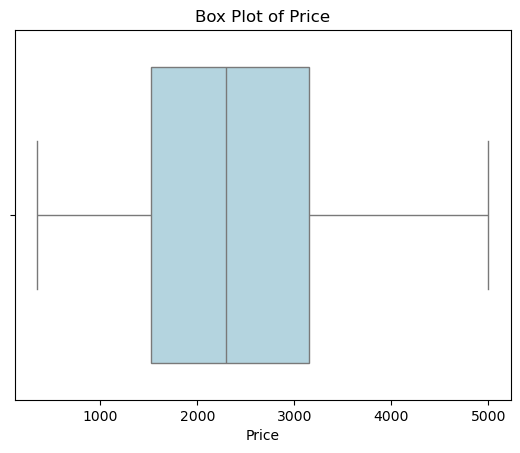

In [6]:
sns.boxplot(x = newdf['price'], color = 'lightblue')
plt.title('Box Plot of Price')
plt.xlabel('Price')
plt.show()

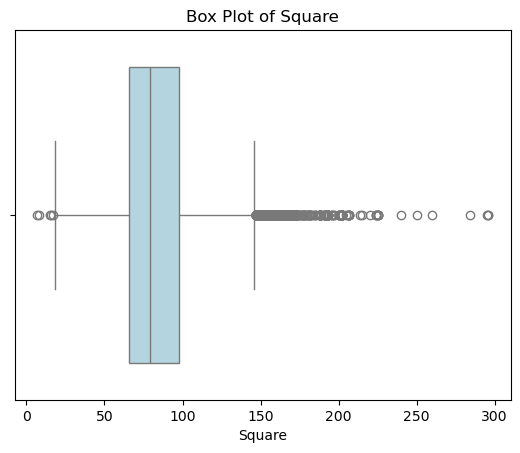

In [7]:
sns.boxplot(x = newdf['square'], color = 'lightblue')
plt.title('Box Plot of Square')
plt.xlabel('Square')
plt.show()

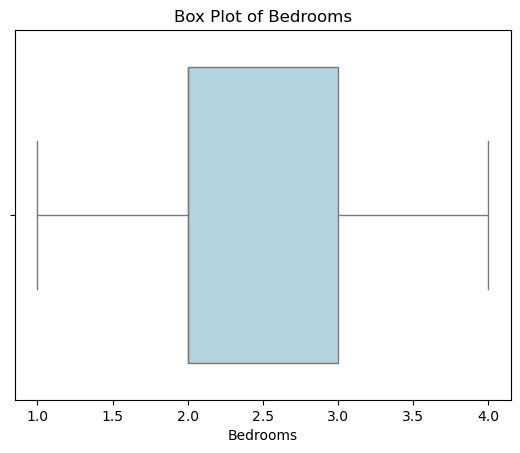

In [8]:
sns.boxplot(x = newdf['bedrooms'], color = 'lightblue')
plt.title('Box Plot of Bedrooms')
plt.xlabel('Bedrooms')
plt.show()

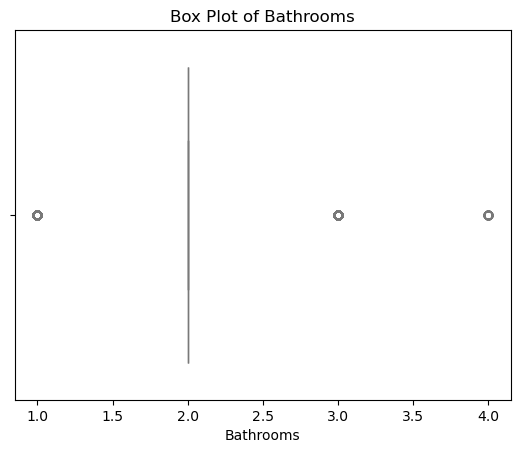

In [9]:
sns.boxplot(x = newdf['bathrooms'], color = 'lightblue')
plt.title('Box Plot of Bathrooms')
plt.xlabel('Bathrooms')
plt.show()

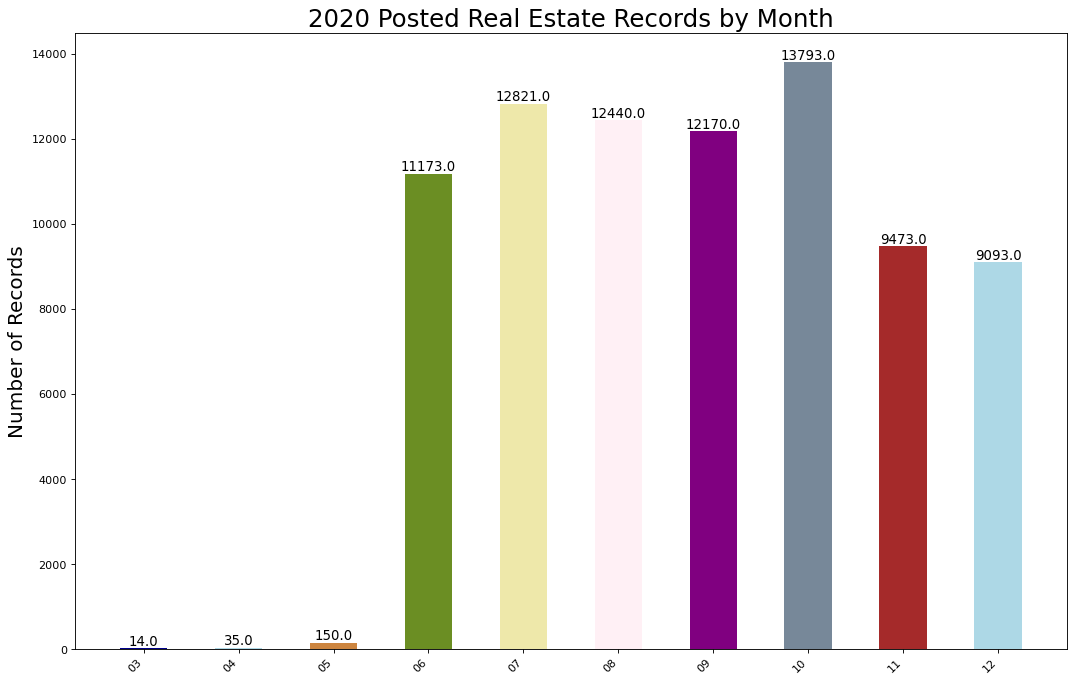

In [10]:
df1 = newdf.groupby('month')['price'].size().reset_index(name = 'number of records')
n = df1['month'].unique().__len__() + 1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k = n)

plt.figure(figsize = (16, 10), dpi = 80)
plt.bar(df1['month'], df1['number of records'], color = c, width = 0.5)
for index, value in enumerate(df1['number of records'].values):
    plt.text(index, value, float(value), horizontalalignment = 'center', verticalalignment = 'bottom', fontdict = {'fontweight': 500, 'size': 12})

plt.gca().set_xticklabels(df1['month'], rotation = 45, horizontalalignment = 'right')
plt.title("2020 Posted Real Estate Records by Month", fontsize = 22)
plt.ylabel("Number of Records", fontsize = 18)
plt.show()

In [11]:
newdf['pricePerSquare'] = np.where(pd.to_numeric(newdf['square'], errors = 'coerce') > 0, pd.to_numeric(newdf['price'], errors = 'coerce') / pd.to_numeric(newdf['square'], errors = 'coerce'), np.nan)
df2 = newdf.groupby('month')['pricePerSquare'].mean().reset_index(name = 'average price')
df2.head()

,month,average price
0,03,26.012028
1,04,23.817814
2,05,26.763475
3,06,28.056225
4,07,28.169838


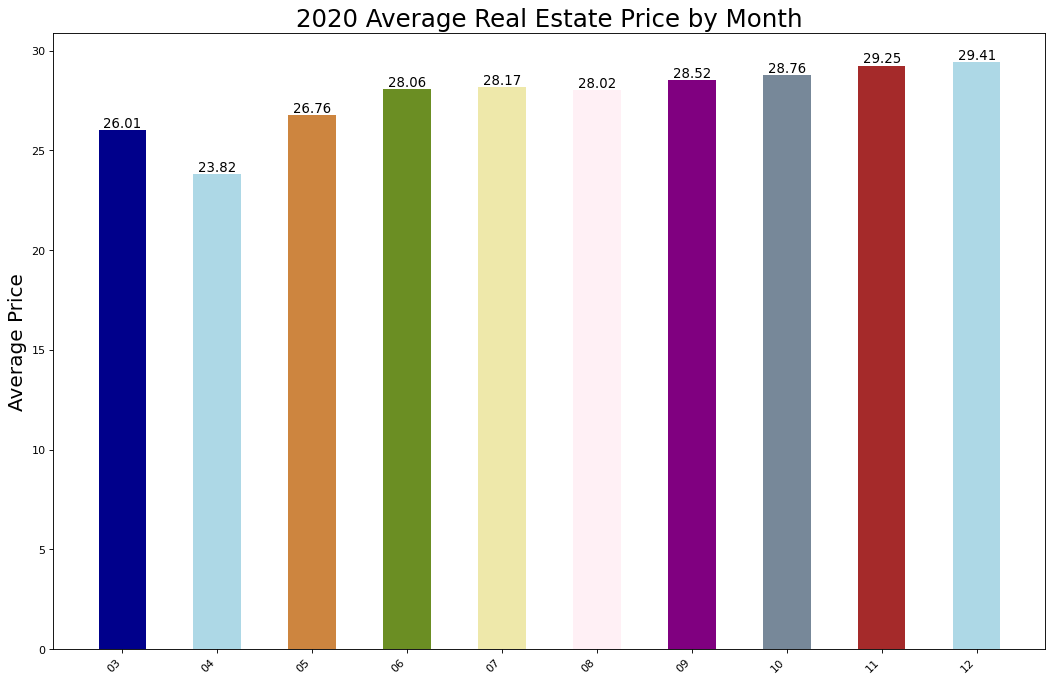

In [12]:
n = df2['month'].unique().__len__() + 1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k = n)
plt.figure(figsize = (16, 10), dpi = 80)
plt.bar(df2['month'], df2['average price'], color = c, width = 0.5)
for index, value in enumerate(df2['average price'].values):
    plt.text(index, value, round(value, 2), horizontalalignment = 'center', verticalalignment = 'bottom', fontdict = {'fontweight': 500, 'size': 12})
plt.gca().set_xticklabels(df2['month'], rotation = 45, horizontalalignment = 'right')
plt.title("2020 Average Real Estate Price by Month", fontsize = 22)
plt.ylabel("Average Price", fontsize = 18)
plt.show()

In [13]:
df3 = newdf[pd.to_numeric(newdf['month'], errors = 'coerce') == 4]
df3.head()

,id,month,project,investor,square,bedrooms,bathrooms,direction,balcony,district,ward,price,pricePerSquare
60585,25281762,04,NaN,NaN,77.0,3.0,2.0,Đông-Bắc,Tây-Nam,hoang mai,hoang liet,1850.0,24.025974
61228,25268074,04,C37 Bộ Công An - Bắc Hà Tower,Công ty CP Xây dựng và Thương mại Bắc Hà,112.0,3.0,2.0,Đông-Nam,Tây-Bắc,nam tu liem,NaN,2688.0,24.000000
61660,19276323,04,Khu đô thị mới Cổ Nhuế,Công ty CP Tập đoàn Nam Cường Hà Nội,150.0,3.0,3.0,NaN,NaN,bac tu liem,co nhue 1,3300.0,22.000000
61960,21153832,04,NaN,NaN,33.0,1.0,1.0,NaN,NaN,nam tu liem,my dinh 2,660.0,20.000000
63490,25200128,04,NaN,NaN,55.0,2.0,1.0,Bắc,Nam,cau giay,mai dich,1260.0,22.909091


In [14]:
df4 = newdf[pd.to_numeric(newdf['month'], errors = 'coerce') == 12]
df4.head()

,id,month,project,investor,square,bedrooms,bathrooms,direction,balcony,district,ward,price,pricePerSquare
0,28086120,12,Vinhomes Smart City Đại Mỗ,Tập đoàn Vingroup,60.0,3.0,1.0,Đông-Nam,Tây-Bắc,nam tu liem,dai mo,1560.0,26.000000
1,28088954,12,Goldmark City,Công ty TNHH Thương mại - Quảng cáo - Xây dựng...,121.0,3.0,2.0,NaN,NaN,bac tu liem,phu dien,3300.0,27.272727
2,28097966,12,Chung cư IEC Tứ Hiệp,NaN,70.0,2.0,2.0,Tây-Bắc,Đông-Nam,thanh tri,tu hiep,1106.0,15.800000
3,27895887,12,Vinhomes D'Capitale,Tân Hoàng Minh Group,39.0,1.0,1.0,Đông-Nam,Đông-Nam,cau giay,trung hoa,1500.0,38.461538
4,28056031,12,The Zen Residence,Công ty TNHH Gamuda Land Việt Nam,97.0,3.0,2.0,NaN,NaN,hoang mai,hoang liet,2900.0,29.896907


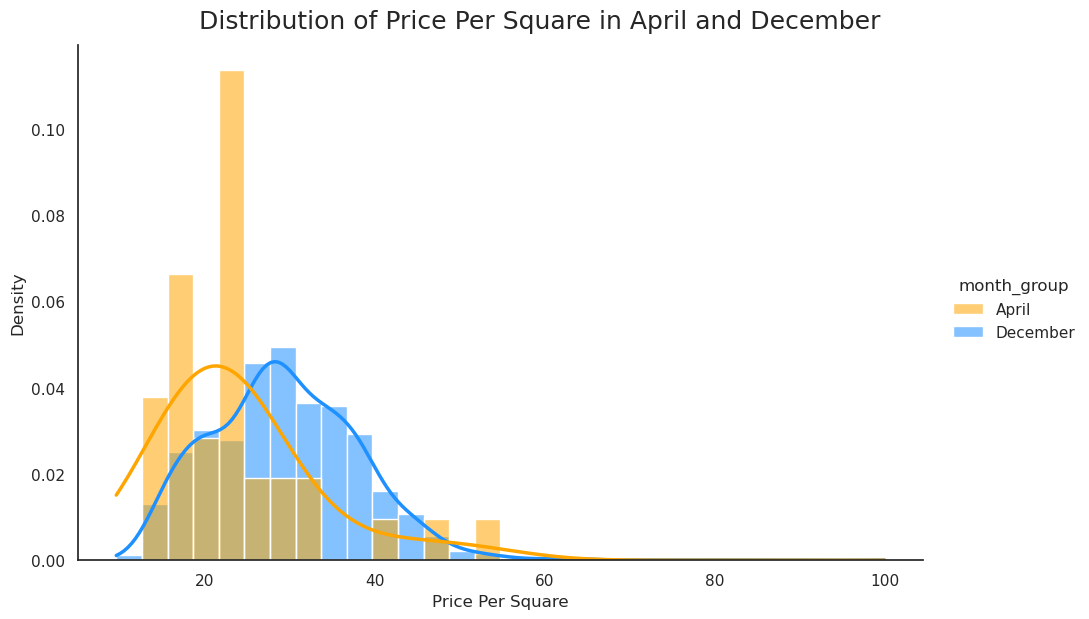

In [15]:
col = 'pricePerSquare'

plot_df = pd.concat([
    df3[[col]].assign(month_group='April'),
    df4[[col]].assign(month_group='December')
]).dropna(subset=[col])

sns.set_theme(style='white')
g = sns.displot(
    data=plot_df,
    x=col,
    hue='month_group',
    kind='hist',
    bins=30,
    stat='density',
    common_norm=False,
    palette={'April': 'orange', 'December': 'dodgerblue'},
    alpha=0.55,
    kde=True,
    kde_kws={'bw_adjust': 1.5, 'cut': 0},
    line_kws={'linewidth': 2.5},
    height=6,
    aspect=1.6
)


g.set_axis_labels('Price Per Square', 'Density')
g.fig.suptitle('Distribution of Price Per Square in April and December', fontsize=18, y=1.03)
plt.show()

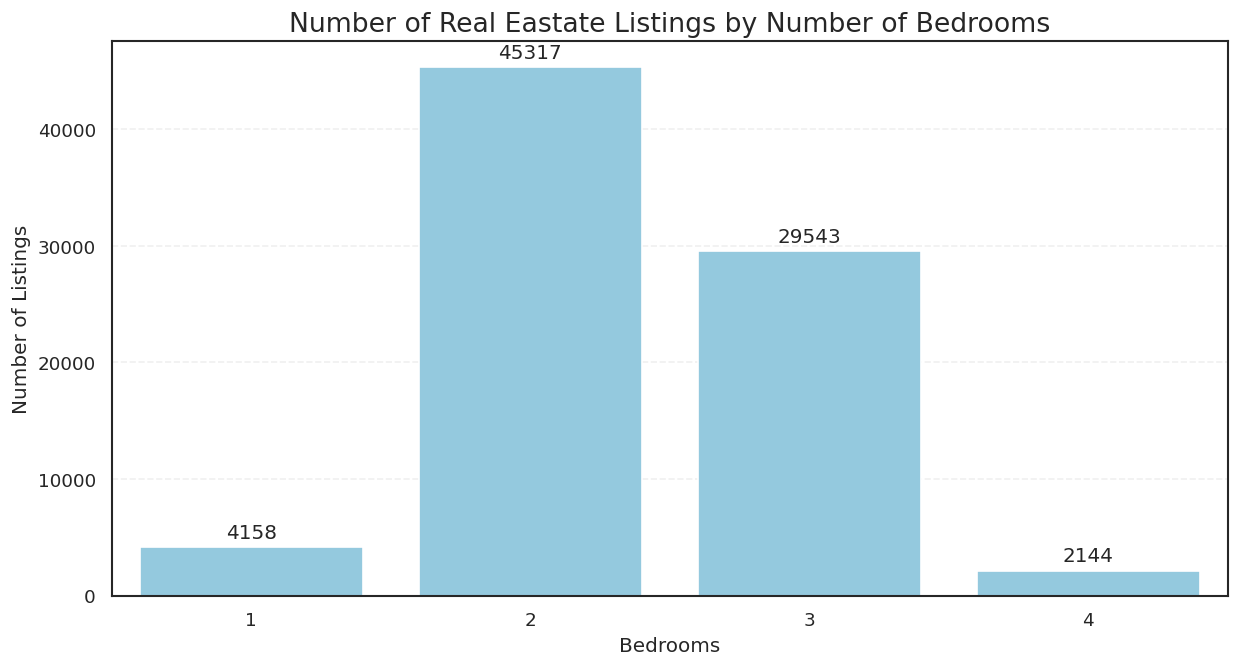

In [16]:
bedroom_counts = (
    pd.to_numeric(newdf['bedrooms'], errors='coerce')
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .reset_index()
 )

bedroom_counts.columns = ['bedrooms', 'count']

plt.figure(figsize=(12, 6), dpi=120)
ax = sns.barplot(data=bedroom_counts, x='bedrooms', y='count', color='skyblue')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Number of Real Eastate Listings by Number of Bedrooms', fontsize=16)
plt.xlabel('Bedrooms', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

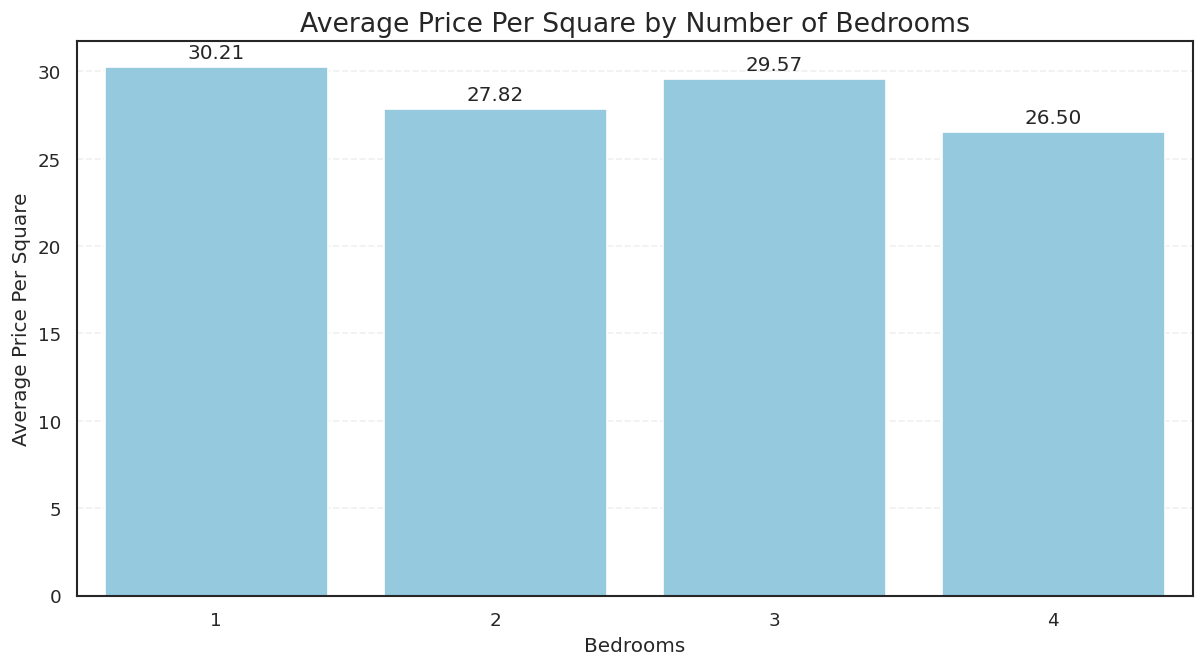

In [17]:
bedroom_price = (
    newdf[['bedrooms', 'pricePerSquare']]
    .assign(
        bedrooms=pd.to_numeric(newdf['bedrooms'], errors='coerce'),
        pricePerSquare=pd.to_numeric(newdf['pricePerSquare'], errors='coerce')
    )
    .dropna(subset=['bedrooms', 'pricePerSquare'])
 )

bedroom_price['bedrooms'] = bedroom_price['bedrooms'].astype(int)
bedroom_price = (
    bedroom_price.groupby('bedrooms', as_index=False)['pricePerSquare']
    .mean()
    .sort_values('bedrooms')
 )

plt.figure(figsize=(12, 6), dpi=120)
ax = sns.barplot(data=bedroom_price, x='bedrooms', y='pricePerSquare', color='skyblue')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Average Price Per Square by Number of Bedrooms', fontsize=16)
plt.xlabel('Bedrooms', fontsize=12)
plt.ylabel('Average Price Per Square', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

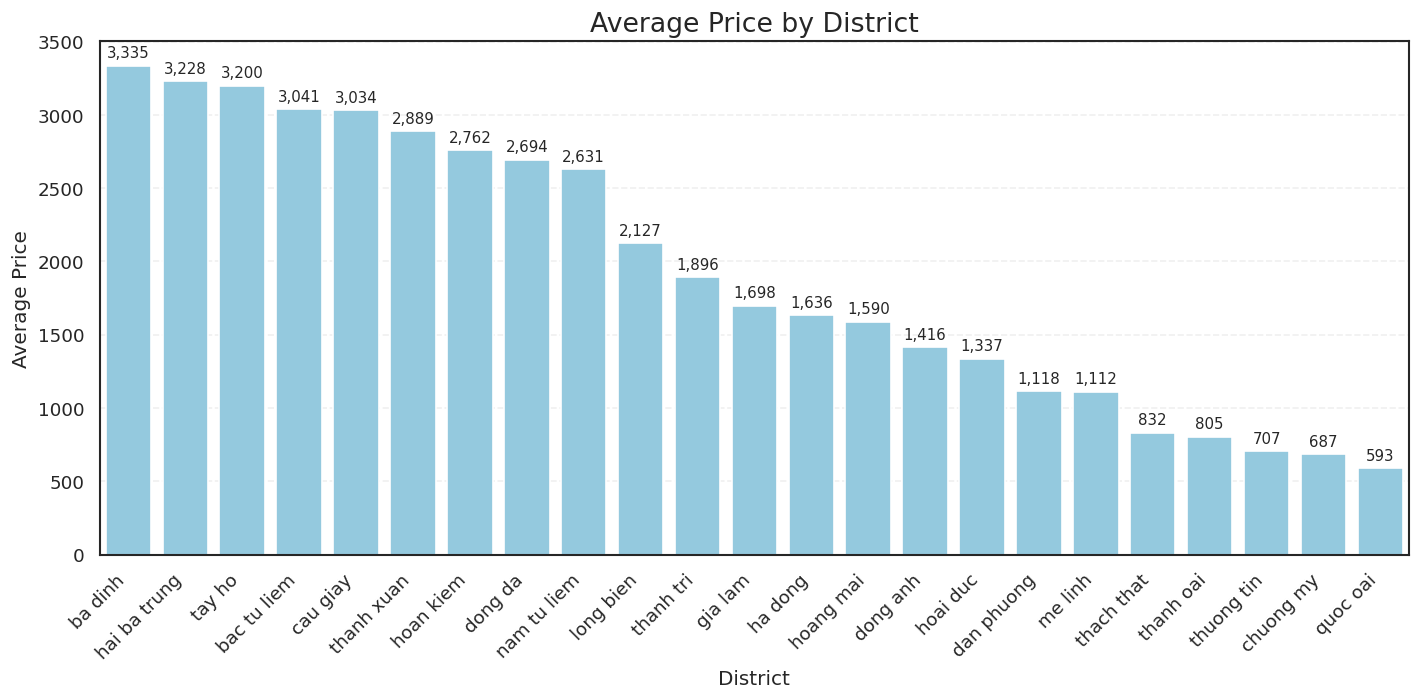

In [18]:
district_price = (
    newdf[['district', 'price']]
    .assign(
        price = pd.to_numeric(newdf['price'], errors='coerce')
    )
    .dropna(subset=['district', 'price'])
)

district_price['district'] = district_price['district'].astype(str)
district_price = (
    district_price.groupby('district', as_index=False)['price']
    .mean()
    .sort_values('price', ascending=False)
)

plt.figure(figsize=(12, 6), dpi=120)
ax = sns.barplot(data=district_price, x='district', y='price', color='skyblue')

for container in ax.containers:
    labels = [f"{v:,.0f}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.title('Average Price by District', fontsize=16)
plt.xlabel('District', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

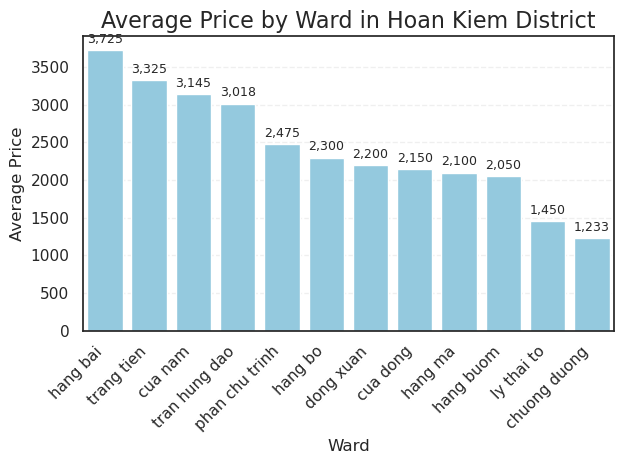

In [19]:
hoan_kiem = newdf[newdf['district'] == 'hoan kiem']
hoan_kiem.head()
hoan_kiem = hoan_kiem.assign(
    pricePerSquare = pd.to_numeric(hoan_kiem['pricePerSquare'], errors='coerce'),
    price = pd.to_numeric(hoan_kiem['price'], errors='coerce')
).dropna(subset=['pricePerSquare', 'price'])
hoan_kiem.head()

hoan_kiem['ward'] = hoan_kiem['ward'].astype(str)
ward_price = hoan_kiem.groupby('ward', as_index=False)['price'].mean().sort_values('price', ascending=False)

ax = sns.barplot(data=ward_price, x='ward', y='price', color='skyblue')
for container in ax.containers:
    labels = [f"{v:,.0f}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)
plt.title('Average Price by Ward in Hoan Kiem District', fontsize=16)
plt.xlabel('Ward', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

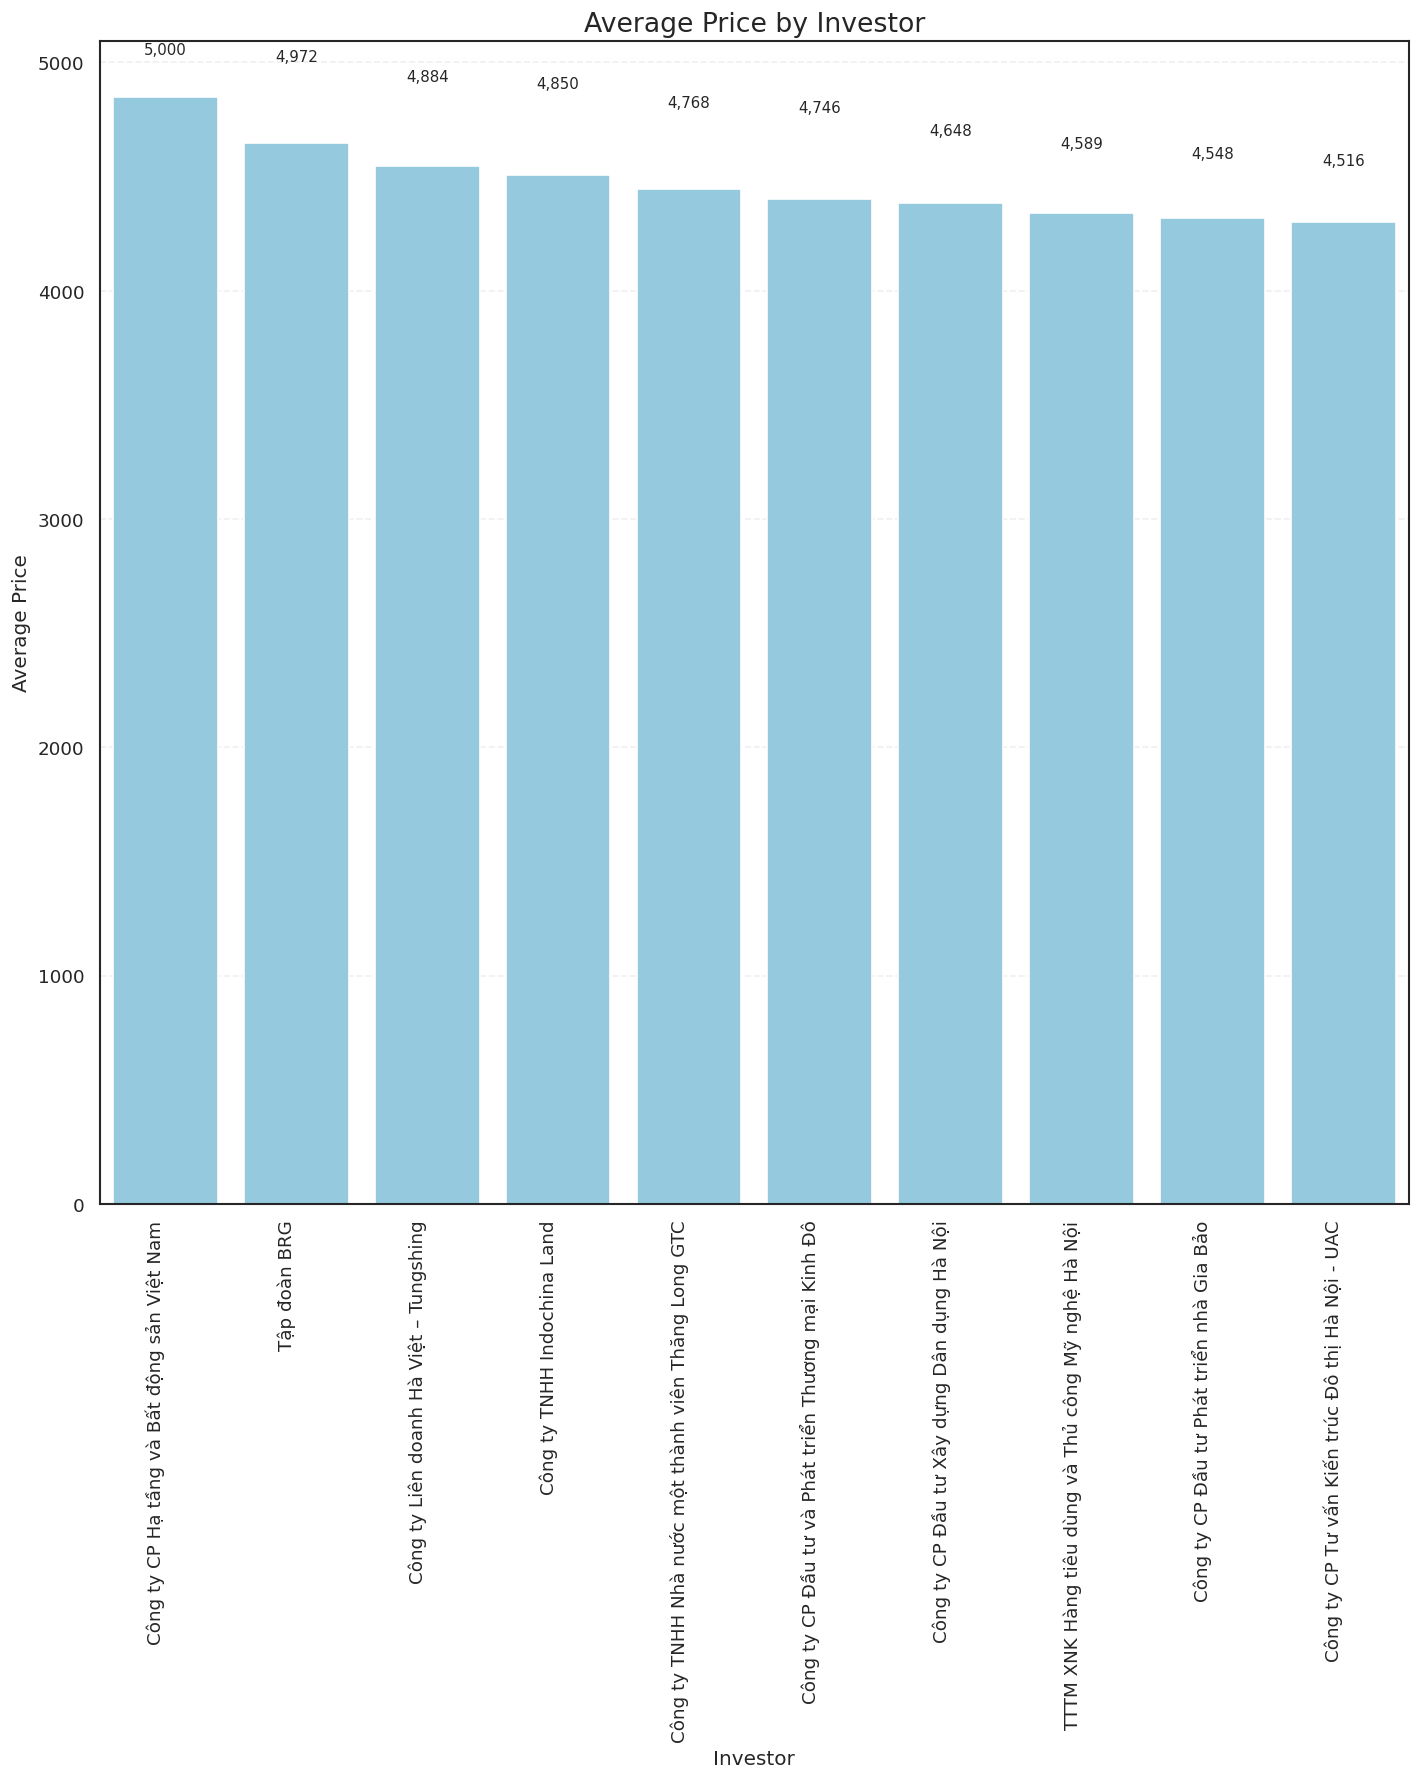

In [31]:
investor = newdf[['investor']].assign(
    price = pd.to_numeric(newdf['price'], errors='coerce')
).dropna(subset=['price', 'investor'])

investor = investor.groupby('investor', as_index=False)['price'].mean().sort_values('price', ascending=False)

plt.figure(figsize=(12, 15), dpi=120)
ax = sns.barplot(data = investor.head(10), x = 'investor', y = 'price', color = 'skyblue')
for continer in ax.containers:
    labels = [f"{v:,.0f}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.title('Average Price by Investor', fontsize=16)
plt.xlabel('Investor', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

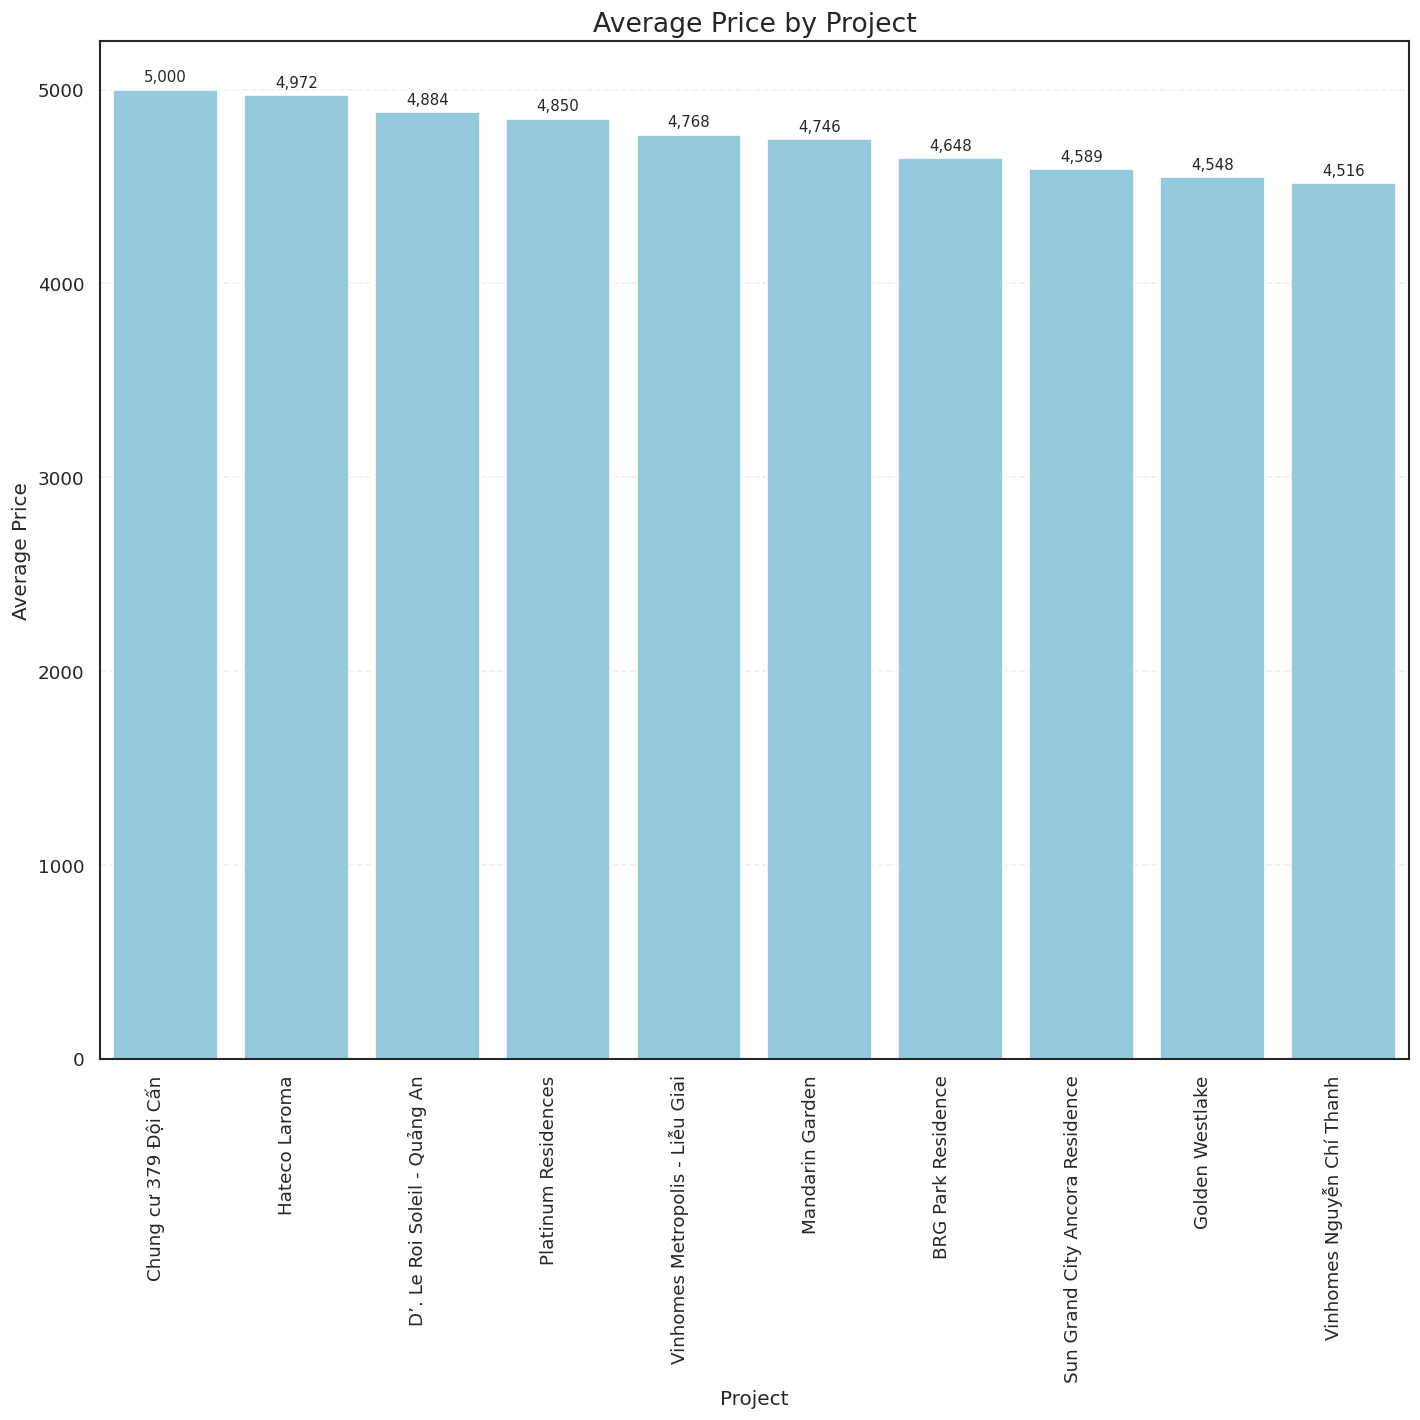

In [25]:
project_price = newdf[['project']].assign(
    price = pd.to_numeric(newdf['price'], errors='coerce')
).dropna(subset=['price', 'project'])
project_price = project_price.groupby('project', as_index=False)['price'].mean().sort_values('price', ascending=False)

plt.figure(figsize=(12, 12), dpi=120)
ax = sns.barplot(data = project_price.head(10), x = 'project', y = 'price', color = 'skyblue')

for container in ax.containers:
    labels = [f"{v:,.0f}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.title('Average Price by Project', fontsize=16)
plt.xlabel('Project', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

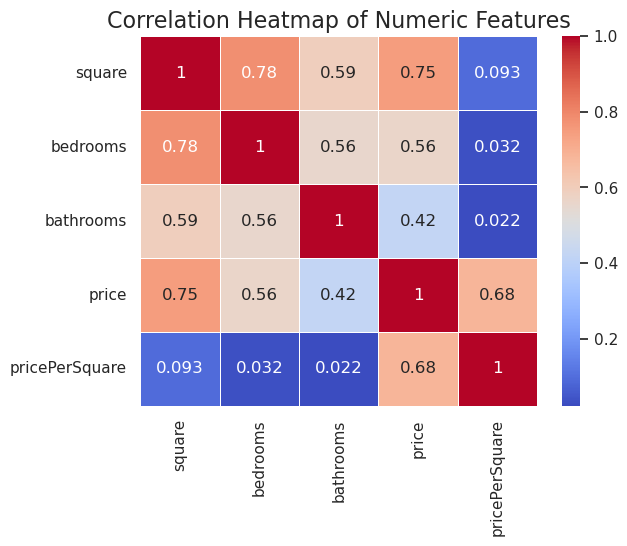

In [33]:
sns.heatmap(newdf.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=16)
plt.show()

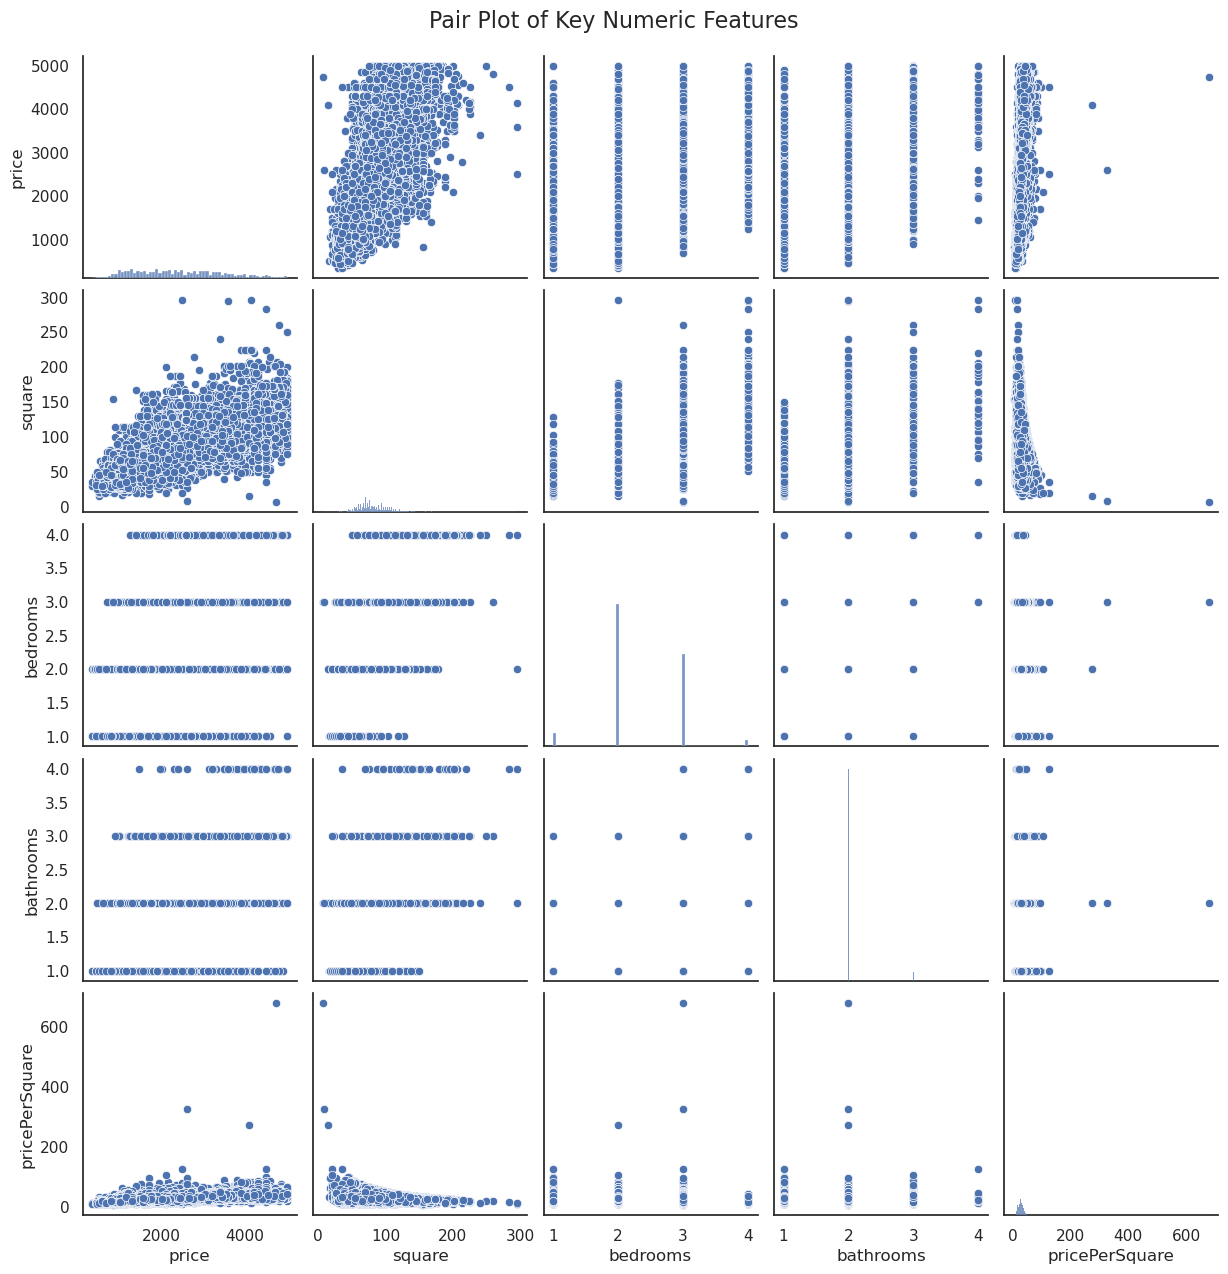

In [35]:
sns.pairplot(newdf, vars = ['price', 'square', 'bedrooms', 'bathrooms', 'pricePerSquare'], kind = 'scatter')
plt.suptitle('Pair Plot of Key Numeric Features', fontsize=16, y=1.02)
plt.show()

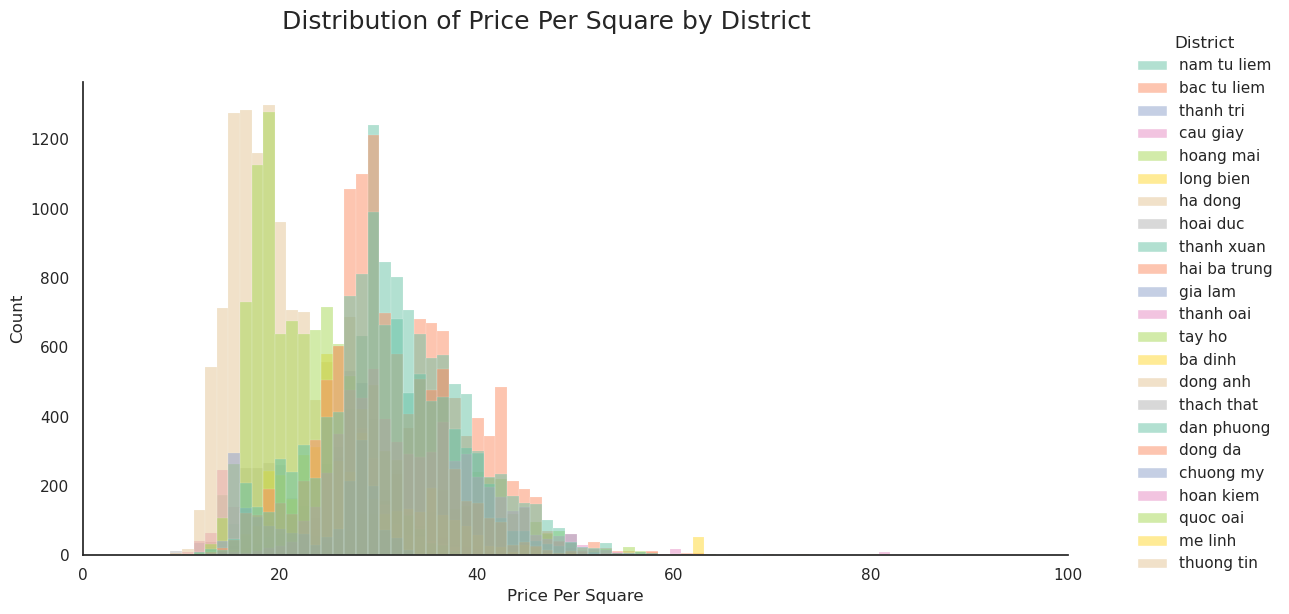

In [42]:
g = sns.displot(
    data=newdf,
    x='pricePerSquare',
    hue='district',
    palette='Set2',
    height=6,
    aspect=1.6
 )

g.set(xlim=(0, 100))
g.set_axis_labels('Price Per Square', 'Count')
g.fig.suptitle('Distribution of Price Per Square by District', fontsize=18, y=1.02)

# Move legend outside so it does not overlap the chart area
sns.move_legend(g, 'upper left', bbox_to_anchor=(1.02, 1), title='District')
g.fig.subplots_adjust(right=0.78)
g.fig.tight_layout()

plt.show()